<a href="https://colab.research.google.com/github/ken14121/-_loadto-/blob/main/%E3%83%87%E3%83%BC%E3%82%BF%E8%A7%A3%E6%9E%903_0605.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**pandas復習**

In [1]:
import pandas as pd

data = {
    "日付": ["2026-05-01", "2026-05-02", "2026-05-03", "2026-05-04", "2026-05-05"],
    "天気": ["晴れ", "曇り", "雨", "晴れ", "晴れ"],
    "大人": [1200, 950, 420, 1500, 1650],
    "子供": [450, 320, 110, 850, 980],
    "高校生": [300, 280, 90, 400, 420],
}

df = pd.DataFrame(data)
df

,日付,天気,大人,子供,高校生
0,2026-05-01,晴れ,1200,450,300
1,2026-05-02,曇り,950,320,280
2,2026-05-03,雨,420,110,90
3,2026-05-04,晴れ,1500,850,400
4,2026-05-05,晴れ,1650,980,420


In [2]:
print(df)

           日付  天気    大人   子供  高校生
0  2026-05-01  晴れ  1200  450  300
1  2026-05-02  曇り   950  320  280
2  2026-05-03   雨   420  110   90
3  2026-05-04  晴れ  1500  850  400
4  2026-05-05  晴れ  1650  980  420


In [3]:
df.iloc[0:3, 0:3]

,日付,天気,大人
0,2026-05-01,晴れ,1200
1,2026-05-02,曇り,950
2,2026-05-03,雨,420


In [4]:
df.loc[0:2, ["日付", "天気", "大人"]]

,日付,天気,大人
0,2026-05-01,晴れ,1200
1,2026-05-02,曇り,950
2,2026-05-03,雨,420


ilocは位置指定で、Pythonのスライスと同じく終端は含まない。

df.iloc[0:3, 0:3]
これは

行 0, 1, 2
列 0, 1, 2
を取るので、3行3列になる。

一方locはラベル指定で終端を含む。

df.loc[0:2, ["日付", "天気", "大人"]]
これは

行ラベル 0, 1, 2
列名 日付, 天気, 大人
を取るので、これも3行3列。
つまり、

iloc[0:3] は「0から3の手前まで」
loc[0:2] は「0から2まで含む」
という違い。

C言語っぽく言うと、

iloc は for(i=0; i<3; i++) に近い
loc は「0から2を全部指定する」感じ。

iloc = 数字で場所、終わりは含まない
loc = 名前で場所、終わりも含む

In [5]:
df["総客数"] = df["大人"] + df["子供"] + df["高校生"]
df

,日付,天気,大人,子供,高校生,総客数
0,2026-05-01,晴れ,1200,450,300,1950
1,2026-05-02,曇り,950,320,280,1550
2,2026-05-03,雨,420,110,90,620
3,2026-05-04,晴れ,1500,850,400,2750
4,2026-05-05,晴れ,1650,980,420,3050


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 22823 (\N{CJK UNIFIED IDEOGRAPH-5927}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 20154 (\N{CJK UNIFIED IDEOGRAPH-4EBA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 32207 (\N{CJK UNIFIED IDEOGRAPH-7DCF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 23458 (\N{CJK UNIFIED IDEOGRAPH-5BA2}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  fig.canvas

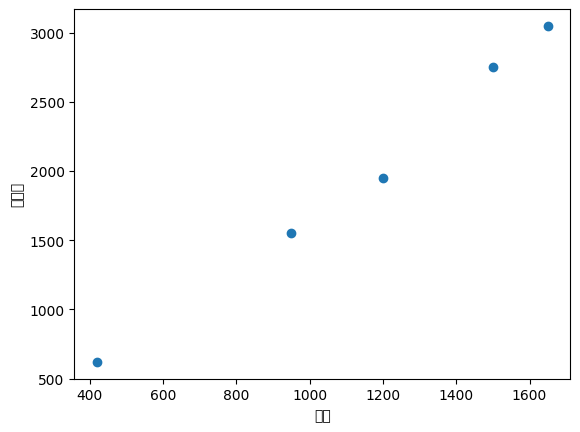

In [6]:
#ここで見たいのはxが増えるとyも増えそうか、つまり相関があるか。
#Matplotlib では「データを渡して、描画命令を出す」だけで済む。
import matplotlib.pyplot as plt

plt.scatter(df["大人"], df["総客数"])
plt.xlabel("大人")
plt.ylabel("総客数")
plt.show()

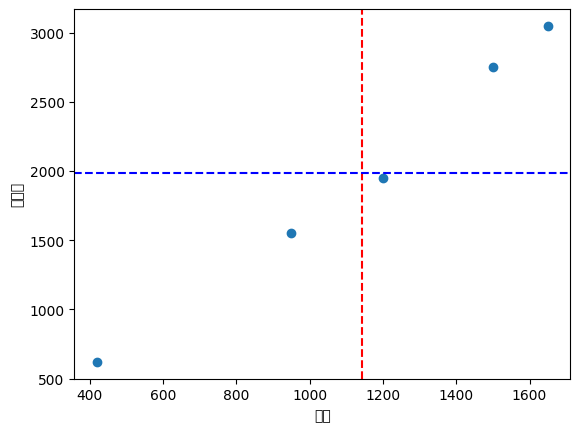

In [7]:
x_mean = df["大人"].mean()
y_mean = df["総客数"].mean()

plt.scatter(df["大人"], df["総客数"])
plt.axvline(x_mean, color="red", linestyle="--")
plt.axhline(y_mean, color="blue", linestyle="--")
plt.xlabel("大人")
plt.ylabel("総客数")
plt.show()

第2象限|第1象限
---------------
_________
第3象限|第4象限
---------------

In [8]:
import numpy as np

x = df["大人"]
y = df["総客数"]

a, b = np.polyfit(x, y, 1)
a, b

(np.float64(1.9857341830920523), np.float64(-287.6799054573074))

In [9]:
print(f"総客数 = {a:.3f} × 大人 + {b:.3f}")

総客数 = 1.986 × 大人 + -287.680


傾き 1.986


大人が1人増えると、総客数はだいたい1.986人増える


切片 -287.680


大人が0人のときの理論上の値


現実では意味が薄いことも多いけど、直線を決めるためにh必要

これは「1次関数」。
ただしデータ解析では、単なる数学の式ではなく予測モデルとして使う。

次はこの式で、大人 = 1400 のときの総客数を予測する。


In [10]:
adult = 1400
pred = a * adult + b
print(f"大人が{adult}人なら、総客数は{pred:.0f}人くらい")

大人が1400人なら、総客数は2492人くらい


In [11]:
adult = 1400
pred = a * adult + b
print(pred)

2492.347950871566


**ここから今日の学習範囲**

**重回帰分析**

単回帰は「説明変数が1つ」。たとえば、

大人 → 総客数

重回帰はここから一歩進んで、複数の説明変数を同時に使う形。

大人
子供
天気
曜日
祝日かどうか
みたいな複数の材料を使って、総客数を予測する。

In [12]:
import pandas as pd
import numpy as np

df = pd.DataFrame({
    "大人": [1200, 950, 420, 1500, 1650],
    "子供": [450, 320, 110, 850, 980],
    "総客数": [1950, 1550, 620, 2750, 3050]
})

X = df[["大人", "子供"]]
y = df["総客数"]

#Xは大人と子供という入力yは総客数という答え。
#C言語で言うと、X は入力用の2次元配列、y は正解データの1次元配列みたいな役。
#fit(X, y) は、この入力からこの答えを出す式を学んでくださいとモデルに渡している感じ。

X, y

(     大人   子供
 0  1200  450
 1   950  320
 2   420  110
 3  1500  850
 4  1650  980,
 0    1950
 1    1550
 2     620
 3    2750
 4    3050
 Name: 総客数, dtype: int64)

In [13]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X, y)

print("係数:", model.coef_)
print("切片:", model.intercept_)

#fit() = 学習して値を決める
#coef_ = 学習結果として保存された係数
#intercept_ = 学習結果として保存された切片

係数: [1.31941163 0.92598864]
切片: -27.29274426068787


In [14]:
pred = model.predict(X)
print(pred)

[1972.69609631 1522.46466635  628.71888957 2738.91504027 3057.20530749]


df["誤差"].abs()
で、誤差の絶対値を取ります。
これは「プラスでもマイナスでも、外れた大きさだけを見る」ため。

df["誤差"].abs().mean()
で、その絶対誤差の平均を取っています。
つまり

1件ごとのズレを全部見る
そのズレの平均を出すをやっている

In [15]:
df["予測値"] = pred
df

,大人,子供,総客数,予測値
0,1200,450,1950,1972.696096
1,950,320,1550,1522.464666
2,420,110,620,628.718890
3,1500,850,2750,2738.915040
4,1650,980,3050,3057.205307


In [16]:
df["予測値"] = pred
df["誤差"] = df["総客数"] - df["予測値"]
df

,大人,子供,総客数,予測値,誤差
0,1200,450,1950,1972.696096,-22.696096
1,950,320,1550,1522.464666,27.535334
2,420,110,620,628.718890,-8.718890
3,1500,850,2750,2738.915040,11.084960
4,1650,980,3050,3057.205307,-7.205307


In [17]:
print(df["誤差"].abs().mean())

#df["誤差"] をabs() に入れてその結果を mean() に入れている

15.448117351557698


In [18]:
error_abs = df["誤差"].abs()
error_mean = error_abs.mean()
print(error_abs)
print(error_mean)

0    22.696096
1    27.535334
2     8.718890
3    11.084960
4     7.205307
Name: 誤差, dtype: float64
15.448117351557698


pandas.df.abs() メソッドは、DataFrame内の数値要素を絶対値に変換するために使用されます。負の値は正の値に変換され、正の値はそのまま保持されます。

Pandasのmeanメソッドは、データフレームやシリーズの平均値を計算するために使用されます。列ごとや行ごとの平均値を簡単に求めることができます。